In [1]:
# Import libraries
import pickle
import numpy as np
import anndata as ad
import pandas as pd
import scanpy as sc
import scipy
import scipy.sparse as sp 
import matplotlib.pyplot as plt
import anndata
from anndata import AnnData

# For plotting
import seaborn as sns

# For PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# For umap
import umap

# SCVI
import scvi
import cellxgene_census
import cellxgene_census.experimental

# For ML training
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
from scipy.sparse import issparse, vstack

/nfs/sw/easybuild/software/custom-conda/geneformer-1.0/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/nfs/home/aoku/.local/lib/python3.10/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
# For geneformer
from geneformer import EmbExtractor
from geneformer import TranscriptomeTokenizer

In [3]:
import warnings

# Suppress specific types of warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [4]:
# Load path (path contains seurat object with our annotations)
czi_path = "/gpfs/commons/groups/compbio/projects/CZI_endom/RNA_temp/62_harmony_102224_Seuratv34_newannot_counts.h5ad"

# Read the h5ad file
adata = sc.read_h5ad(czi_path)

print(adata)

AnnData object with n_obs × n_vars = 171459 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'peak_region_fragments', 'pct_reads_in_peaks', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'blacklist_fraction', 'nCount_GA', 'nFeature_GA', 'Percent_mito', 'S.Score', 'G2M.Score', 'Phase', 'qc', 'atac_qc', 'sample', 'RNA_snn_res.0.1', 'seurat_clusters', 'RNA_snn_res.0.2', 'RNA_snn_res.0.5', 'RNA_snn_res.0.8', 'RNA.weight', 'ATAC.weight', 'nCount_HTO', 'nFeature_HTO', 'doubletdetection', 'RNA_type', 'freemuxlet_doublet', 'freemuxlet_genotype', 'libnorm_demux', 'genotype_call', 'hto_call', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'DoubletScore', 'DoubletEnrichment', 'BlacklistRatio', 'AMULET.p.value', 'AMULET.q.value', 'AMULET.final', 'ATAC_PASS', 'id', 'RNA_snn_res.0.4', 'menopaus

In [5]:
# Get counts data (scVi requires count info)
adata.layers["counts"] = adata.raw.X.copy()
adata.layers["logcounts"] = adata.X.copy()

In [6]:
# Add HECA annotations to adata (annotation from published HECA dataset)
heca_annot = pd.read_csv("/nfs/home/rfu/projects/CZI_endom/CZI_HECAtype.csv.gz")

# Check if cell index matches
print(pd.Series(adata.obs_names == heca_annot.cell).value_counts())

# Add to anndata
adata.obs["heca_celltype"] = heca_annot["celltype"].values
adata.obs["heca_lineage"] = heca_annot["lineage"].values

True    171459
Name: count, dtype: int64


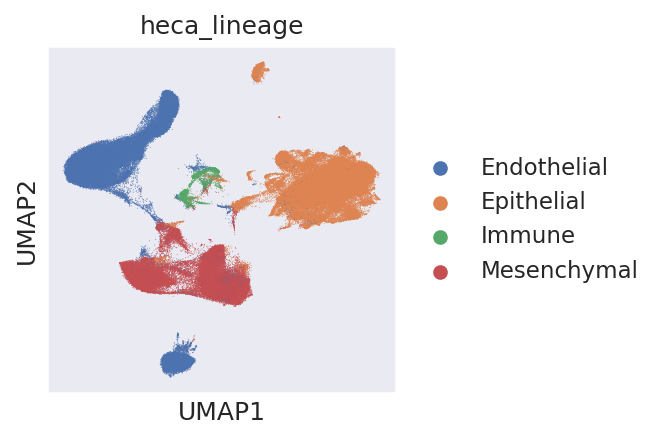

In [7]:
with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": (150)}):
    sc.pl.umap(adata, color='heca_lineage')

In [8]:
# Prep data for scVI

#Get ensembl IDs - map gene symbol to ensembl ID
gene_ids = pd.read_csv("/gpfs/commons/groups/compbio/projects/CZI_endom/RNA_temp/gene_names_gene_ids_czi_endo.csv", index_col= False)

gene_id_dict = pd.DataFrame({
    'gene_symbol': gene_ids["gene_name"],
    'ensembl_id': gene_ids["gene_id"]})

gene_id_dict = gene_id_dict.set_index('gene_symbol')['ensembl_id'].to_dict()

ensembl_ids = [gene_id_dict.get(gene, 'NA') for gene in adata.var_names]

# Add ensembl IDs to anndata object
adata.var["gene_names"] = adata.var_names
adata.var["ensembl_id"] = ensembl_ids
adata.var_names = ensembl_ids

# Remove duplicated IDs
adata = adata[:, ~adata.var["ensembl_id"].duplicated()].copy()

# Check for duplicated IDs
adata.var["ensembl_id"].duplicated().any()

del adata.varm["HARMONY"]
del adata.varm["PCs"]

In [9]:
adata.obs["cell_index"]  = adata.obs.index #required for geneformer
adata.obs["cell_id"] = adata.obs["cell_index"] #required for geneformer

In [10]:
adata.obs['n_counts'] = np.array(adata.X.sum(axis=1)).flatten() #number of transcripts per cell

In [11]:
#### Split data into training and testing sets
# Get unique sample IDs
unique_ids = adata.obs['id'].unique()

# Split the sample IDs
train_ids, test_ids = train_test_split(unique_ids, test_size=0.15, random_state=42)

# Create boolean masks
train_mask = adata.obs['id'].isin(train_ids)
test_mask = adata.obs['id'].isin(test_ids)

# Subset the AnnData object
adata_train = adata[train_mask].copy()
adata_test = adata[test_mask].copy()

In [12]:
#adata_test.obs["heca_lineage"].value_counts()
len(adata_test.obs["id"].unique())

10

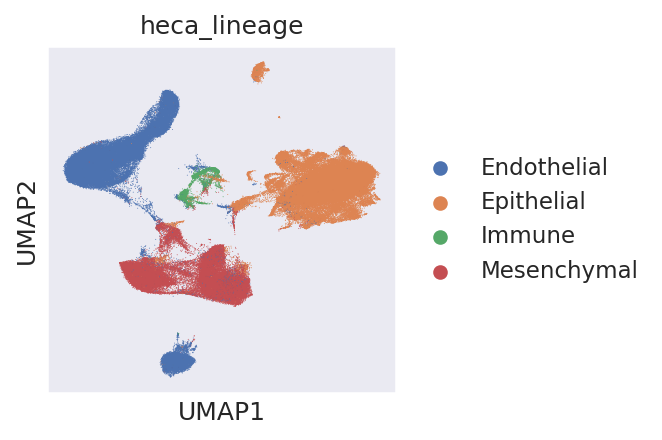

In [13]:
with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": (150)}):
    sc.pl.umap(adata_train, color='heca_lineage')

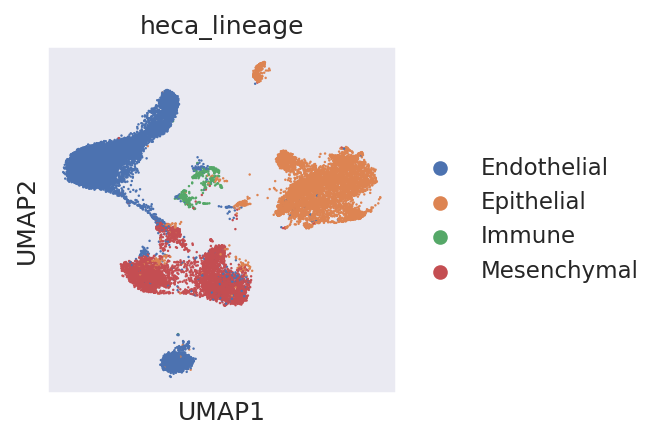

In [14]:
with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": (150)}):
    sc.pl.umap(adata_test, color='heca_lineage')

In [15]:
#adata.write_h5ad("/gpfs/commons/groups/compbio/projects/CZI_endom/RNA_temp/geneformer_deconv/62_harmony_102224_Seuratv34_newannot_for_geneformer_plus_heca_annot.h5ad")

In [16]:
print(adata)

AnnData object with n_obs × n_vars = 171459 × 36592
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'peak_region_fragments', 'pct_reads_in_peaks', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'blacklist_fraction', 'nCount_GA', 'nFeature_GA', 'Percent_mito', 'S.Score', 'G2M.Score', 'Phase', 'qc', 'atac_qc', 'sample', 'RNA_snn_res.0.1', 'seurat_clusters', 'RNA_snn_res.0.2', 'RNA_snn_res.0.5', 'RNA_snn_res.0.8', 'RNA.weight', 'ATAC.weight', 'nCount_HTO', 'nFeature_HTO', 'doubletdetection', 'RNA_type', 'freemuxlet_doublet', 'freemuxlet_genotype', 'libnorm_demux', 'genotype_call', 'hto_call', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'DoubletScore', 'DoubletEnrichment', 'BlacklistRatio', 'AMULET.p.value', 'AMULET.q.value', 'AMULET.final', 'ATAC_PASS', 'id', 'RNA_snn_res.0.4', 'menopaus

### Tokenize data

### Create Geneformer Embeddings

In [18]:
from geneformer import EmbExtractor

### Create Pseudobulk

In [25]:
import anndata
import pandas as pd
import numpy as np
from sklearn.utils import check_random_state
import warnings

def create_proportional_pseudobulks(
    adata: anndata.AnnData,  # anndata object from a single sample
    cell_type_col: str,      # column name corresponding to the cell type
    n_pseudobulks: int = 1000,
    target_proportion_min: float = 0.1,
    target_proportion_max: float = 0.9,
    n_cells_per_pseudobulk: int = 800, # Fixed number of cells per pseudobulk
    random_state: int = 42
) -> tuple[pd.DataFrame, pd.DataFrame]:

    # --- Input Validation ---
    if cell_type_col not in adata.obs.columns:
        raise ValueError(f"Cell type column '{cell_type_col}' not found in adata.obs.")
    if not (0 <= target_proportion_min < target_proportion_max <= 1):
        raise ValueError("target_proportion_min must be less than target_proportion_max, "
                         "and both must be between 0 and 1.")
    if not (n_cells_per_pseudobulk > 0):
        raise ValueError("n_cells_per_pseudobulk must be greater than 0.")

    # --- Setup ---
    rng = check_random_state(random_state)
    all_cell_types = adata.obs[cell_type_col].unique()
    
    # Check if there are at least two cell types to allow for "other" cells
    if len(all_cell_types) < 2 and (target_proportion_max < 1.0 or target_proportion_min > 0.0):
        warnings.warn("Less than 2 unique cell types found. Proportional mixing might be limited "
                      "if target_proportion_min is not 0.0 or target_proportion_max is not 1.0.")
    elif len(all_cell_types) < 1:
        warnings.warn("No cell types found in adata.obs. Returning empty DataFrames.")
        return pd.DataFrame(), pd.DataFrame()

    pseudobulk_data_list = []
    proportions_data_list = []
    pseudobulk_sample_names = []

    # Generate random target proportions
    target_proportions = rng.uniform(low=target_proportion_min, high=target_proportion_max, size=n_pseudobulks)
    
    # Cycle through cell types to be the 'target'
    cell_type_cycle = np.tile(all_cell_types, int(np.ceil(n_pseudobulks / len(all_cell_types))))[:n_pseudobulks]

    # Group cells by cell type for efficient sampling
    grouped_cells = adata.obs.groupby(cell_type_col).apply(lambda x: x.index.tolist()).to_dict()

    # --- Create multiple pseudobulks based on controlled proportions ---
    for i in range(n_pseudobulks):
        target_cell_type = cell_type_cycle[i]
        current_target_prop = target_proportions[i]

        # Calculate cell counts for target and other cells
        n_target_cells = int(np.round(n_cells_per_pseudobulk * current_target_prop))
        n_target_cells = max(0, min(n_target_cells, n_cells_per_pseudobulk)) # Ensure within bounds

        n_other_cells = n_cells_per_pseudobulk - n_target_cells

        selected_indices = []

        # 1. Sample Target Cell Type
        if target_cell_type in grouped_cells and len(grouped_cells[target_cell_type]) > 0:
            if n_target_cells > 0:
                target_cell_indices = rng.choice(
                    grouped_cells[target_cell_type],
                    size=n_target_cells,
                    replace=True # Allow replacement to hit exact proportions, even if few cells
                ).tolist()
                selected_indices.extend(target_cell_indices)
        elif n_target_cells > 0:
            warnings.warn(f"Cell type '{target_cell_type}' selected as target for PB_{i+1}, "
                          f"but has no cells. This pseudobulk will have 0% of '{target_cell_type}'.")
            # This pseudobulk will just consist of 'other' cells if target has no cells.

        # 2. Sample "Other" Cell Types
        if n_other_cells > 0:
            other_cell_types = [ct for ct in all_cell_types if ct != target_cell_type]
            
            if len(other_cell_types) > 0:
                # Get all indices of 'other' cell types
                all_other_indices = []
                for ct in other_cell_types:
                    if ct in grouped_cells and len(grouped_cells[ct]) > 0:
                        all_other_indices.extend(grouped_cells[ct])
                
                if len(all_other_indices) > 0:
                    other_cell_selected_indices = rng.choice(
                        all_other_indices,
                        size=n_other_cells,
                        replace=True # Allow replacement for 'other' cells
                    ).tolist()
                    selected_indices.extend(other_cell_selected_indices)
                else:
                    warnings.warn(f"No 'other' cell types available for sampling for PB_{i+1}. "
                                  f"This pseudobulk might consist solely of the target type or be empty.")
            elif n_target_cells == 0: # If no other cell types and no target cells selected
                 warnings.warn(f"No cells available to sample for PB_{i+1}. Skipping this pseudobulk.")
                 continue # Skip to next pseudobulk if no cells can be sampled

        # Handle cases where selected_indices might be empty (e.g., if n_cells_per_pseudobulk is 0 or no cells available)
        if not selected_indices:
            warnings.warn(f"No cells sampled for pseudobulk PB_{i+1}. Skipping this pseudobulk.")
            continue

        # Store the pseudobulk expression
        pb_expression_matrix = adata[selected_indices, :].X
        if isinstance(pb_expression_matrix, (np.ndarray, pd.DataFrame)):
            pb_expression_sum = pb_expression_matrix.sum(axis=0)
        else: # Assume sparse matrix (e.g., scipy.sparse.csr_matrix)
            pb_expression_sum = pb_expression_matrix.sum(axis=0).A1 

        pseudobulk_data_list.append(pb_expression_sum)

        # Calculate and store the actual cell type proportions
        selected_cell_types_series = adata.obs.loc[selected_indices, cell_type_col]
        current_pb_counts = selected_cell_types_series.value_counts()
        current_pb_proportions = current_pb_counts / current_pb_counts.sum()

        proportions_dict = {ct: 0.0 for ct in all_cell_types}
        for ct, prop in current_pb_proportions.items():
            proportions_dict[ct] = prop
        proportions_data_list.append(proportions_dict)

        # Generate a unique name for the pseudobulk sample
        pseudobulk_sample_names.append(f"{target_cell_type}_PB{i+1}")
                
    # --- Create final DataFrames ---
    if not pseudobulk_data_list:
        warnings.warn("No pseudobulk samples were successfully created. Returning empty DataFrames.")
        return pd.DataFrame(), pd.DataFrame()

    pseudobulk_df = pd.DataFrame(
        pseudobulk_data_list,
        index=pseudobulk_sample_names,
        columns=adata.var_names
    )

    proportions_df = pd.DataFrame(
        proportions_data_list,
        index=pseudobulk_sample_names
    )
    # Ensure all_cell_types are columns, filling missing with 0 for consistency
    proportions_df = proportions_df.reindex(columns=all_cell_types, fill_value=0.0)

    return pseudobulk_df, proportions_df

In [26]:
all_pseudobulks = []
all_cell_props = []
id_list = ['B2-CZI08N', 'B3-CZI11N', 'B3-CZI05N']

for sample_id in id_list:
    adata_sub = adata_train[adata_train.obs["id"] == sample_id].copy()
    if adata_sub.n_obs == 0:
        print(f"No cells found for ID: {sample_id}")
        continue

    pseudobulk_czi_temp, pseudobulk_czi_cell_prop_temp = create_proportional_pseudobulks(
        adata=adata_sub,
        cell_type_col="heca_lineage",
        n_cells_per_pseudobulk=800, random_state=42
    )

    all_pseudobulks.append(pseudobulk_czi_temp)
    all_cell_props.append(pseudobulk_czi_cell_prop_temp)

# Concatenate all results
pseudobulk_czi = pd.concat(all_pseudobulks, axis=0, ignore_index=True)
pseudobulk_czi_cell_prop = pd.concat(all_cell_props, axis=0, ignore_index=True)

/tmp/ipykernel_704660/2049627862.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_cells = adata.obs.groupby(cell_type_col).apply(lambda x: x.index.tolist()).to_dict()
/tmp/ipykernel_704660/2049627862.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_cells = adata.obs.groupby(cell_type_col).apply(lambda x: x.index.tolist()).to_dict()
/tmp/ipykernel_704660/2049627862.py:49: DeprecationW

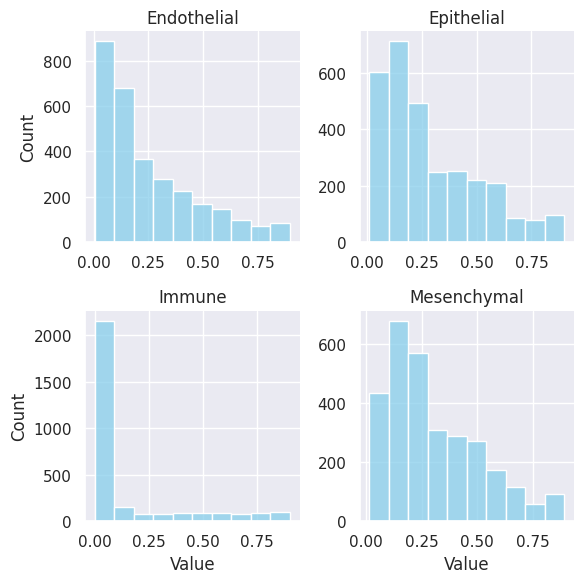

In [27]:
# Explore cell type proportions
# Reshape the data to long format
df_long = pseudobulk_czi_cell_prop.melt(var_name='Variable', value_name='Value')

# Create facet plot
g = sns.FacetGrid(df_long, col='Variable', col_wrap=2, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x='Value', bins=10, color='skyblue')

# Adjust layout
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Value", "Count")
plt.tight_layout()
plt.show()

### Get geneformer embeddings for pseudobulk data

In [45]:
# Create anndata
data2 = pseudobulk_czi
data3 = sc.AnnData(data2)
data3.obs['cell_type'] = "unknown"
data3.obs['n_counts'] = np.sum(data3.X, axis = 1).tolist()
data3.var["ensembl_id"] = data3.var_names
data3.X = scipy.sparse.csc_matrix(data3.X)
data3.write_h5ad("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/train_set.h5ad")

In [46]:
print(data3)

AnnData object with n_obs × n_vars = 3000 × 36592
    obs: 'cell_type', 'n_counts'
    var: 'ensembl_id'


In [47]:
from geneformer import TranscriptomeTokenizer

# Initialize tokenizer
tk = TranscriptomeTokenizer({"cell_type": "cell_type"}, 
                            model_input_size=4096, special_token=True,
                            chunk_size = 512,
                            gene_median_file = "/gpfs/commons/groups/compbio/projects/rf_projects/rf_models/geneformer_pkl/gene_median_dictionary_gc95M.pkl",
                            token_dictionary_file = "/gpfs/commons/groups/compbio/projects/rf_projects/rf_models/geneformer_pkl/token_dictionary_gc95M.pkl",
                            gene_mapping_file = "/gpfs/commons/groups/compbio/projects/rf_projects/rf_models/geneformer_pkl/ensembl_mapping_dict_gc95M.pkl")

# Tokenize data
tk.tokenize_data("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/", 
                 "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/tokenize/", 
                 "token_train_set", 
                 file_format="h5ad")

Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/train_set.h5ad


100%|██████████| 6/6 [00:06<00:00,  1.07s/it]


/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/train_set.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.


In [49]:
from geneformer import perturber_utils as pu

model = pu.load_model(model_type="Pretrained", 
                      num_classes=0, 
                      model_directory="ctheodoris/Geneformer",
                      mode="eval")

import pickle
with open("/gpfs/commons/groups/compbio/projects/rf_condas/geneformer/lib/python3.10/site-packages/geneformer/token_dictionary_gc95M.pkl", "rb") as f:
    gene_token_dict = pickle.load(f)
token_gene_dict = {v: k for k, v in gene_token_dict.items()}
pad_token_id = gene_token_dict.get("<pad>")
# load input
filtered_input_data = pu.load_and_filter(filter_data=None, nproc=1, 
                                         input_data_file="/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/tokenize/token_train_set.dataset/")

BertForMaskedLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


In [51]:
from geneformer import get_embs

state_embs_dict = get_embs(model,
                           filtered_input_data,
                           emb_mode="cell",
                           layer_to_quant=0,
                           pad_token_id=pad_token_id,
                           token_gene_dict=token_gene_dict,
                           special_token=True,
                           forward_batch_size=50)

CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.
100%|██████████| 60/60 [07:42<00:00,  7.71s/it]


In [52]:
tempout = pd.DataFrame.from_dict(state_embs_dict.cpu().numpy())
df = filtered_input_data.to_pandas()
tempout.index = df['cell_type'] + '_' + df.index.astype(str)
tempout.index = data3.obs.index
tempout.to_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/train/gf_pseudobulk_train_set.csv")

## Step: Train Random Forest Regressor --- Start here for training models

In [22]:
# Read in data if necessary
latent_czi_pseudobulk = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/train/gf_pseudobulk_train_set.csv", index_col=0)

In [33]:
# Define X and y 
X = latent_czi_pseudobulk
y = pseudobulk_czi_cell_prop

In [34]:
# Train regressor model
# Split data into training and test splits
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [35]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(2400, 1152)
(2400, 4)
(600, 1152)
(600, 4)


In [52]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=500, random_state=42)
model_rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=500, random_state=42)

In [54]:
# Assuming you have a DataFrame `X_bulk_latent` with same features as `X_train`
y_pred = model_rf.predict(X_test)

# Convert to DataFrame
predicted_proportions = pd.DataFrame(y_pred, columns=y_test.columns, index=X_test.index)

In [55]:
def plot_true_vs_predicted(y_test_df, predicted_proportions, n_cols=4, figsize_per_plot=(3, 3), dot_size=5):

    # Get column names (cell types or lineages)
    cols = predicted_proportions.columns
    n_rows = int(np.ceil(len(cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * figsize_per_plot[0], n_rows * figsize_per_plot[1]))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        x = y_test_df[col]
        y = predicted_proportions[col]

        # Scatterplot
        sns.scatterplot(x=x, y=y, alpha=0.7, ax=ax, s=dot_size)

        # Identity line
        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--')

        # Correlation coefficient
        corr, _ = pearsonr(x, y)
        ax.text(
            0.05, 0.95, f"r = {corr:.2f}",
            transform=ax.transAxes,
            verticalalignment='top',
            fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.5)
        )

        # Titles and labels
        ax.set_title(f'{col}')
        ax.set_xlabel('True')
        ax.set_ylabel('Predicted')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


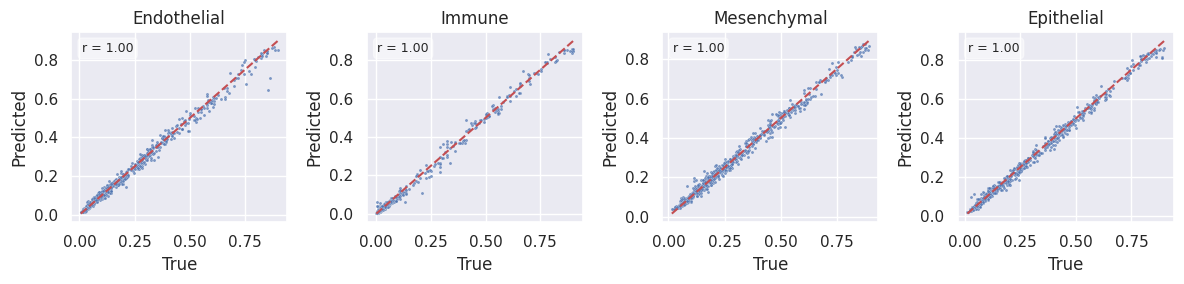

In [56]:
# Plot correlations (pearson)
plot_true_vs_predicted(y_test,predicted_proportions)

## Use randomly sampled pseudobulk 

In [41]:
adata_test_sample = adata_test[adata_test.obs["id"].isin (["B15-CZI251N"])] #"B5-CZI34N"
#adata_test_sample = adata_train[adata_train.obs["id"].isin(["B3-CZI11N"])]
#["B4P4-CZI04N", "B4P1-CZI01N","B3-CZI05N"]

In [42]:
test_czi, test_czi_cell_prop = create_proportional_pseudobulks(adata=adata_test_sample, cell_type_col="heca_lineage", random_state=42)

/tmp/ipykernel_704660/2049627862.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_cells = adata.obs.groupby(cell_type_col).apply(lambda x: x.index.tolist()).to_dict()


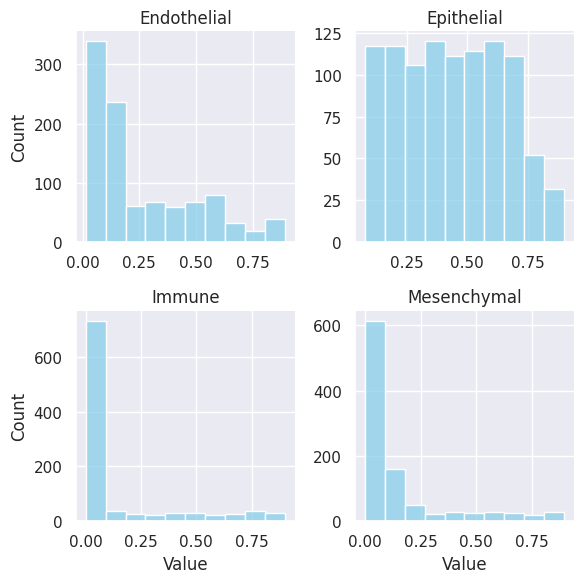

In [43]:
# Explore cell type proportions
# Reshape the data to long format
df_long = test_czi_cell_prop.melt(var_name='Variable', value_name='Value')

# Create facet plot
g = sns.FacetGrid(df_long, col='Variable', col_wrap=2, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x='Value', bins=10, color='skyblue')

# Adjust layout
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Value", "Count")
plt.tight_layout()
plt.show()

In [44]:
# Create anndata
data2 = test_czi
data3 = sc.AnnData(data2)
data3.obs['cell_type'] = "unknown"
data3.obs['n_counts'] = np.sum(data3.X, axis = 1).tolist()
data3.var["ensembl_id"] = data3.var_names
data3.X = scipy.sparse.csc_matrix(data3.X)
data3.write_h5ad("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/test/test_set.h5ad")

In [45]:
from geneformer import TranscriptomeTokenizer

# Initialize tokenizer
tk = TranscriptomeTokenizer({"cell_type": "cell_type"}, 
                            model_input_size=4096, special_token=True,
                            chunk_size = 512,
                            gene_median_file = "/gpfs/commons/groups/compbio/projects/rf_projects/rf_models/geneformer_pkl/gene_median_dictionary_gc95M.pkl",
                            token_dictionary_file = "/gpfs/commons/groups/compbio/projects/rf_projects/rf_models/geneformer_pkl/token_dictionary_gc95M.pkl",
                            gene_mapping_file = "/gpfs/commons/groups/compbio/projects/rf_projects/rf_models/geneformer_pkl/ensembl_mapping_dict_gc95M.pkl")

# Tokenize data
tk.tokenize_data("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/test/", 
                 "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/test/tokenize/", 
                 "token_test_set", 
                 file_format="h5ad")

Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/test/test_set.h5ad


100%|██████████| 2/2 [00:02<00:00,  1.05s/it]


/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/test/test_set.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.


In [46]:
from geneformer import perturber_utils as pu

model = pu.load_model(model_type="Pretrained", 
                      num_classes=0, 
                      model_directory="ctheodoris/Geneformer",
                      mode="eval")

import pickle
with open("/gpfs/commons/groups/compbio/projects/rf_condas/geneformer/lib/python3.10/site-packages/geneformer/token_dictionary_gc95M.pkl", "rb") as f:
    gene_token_dict = pickle.load(f)
token_gene_dict = {v: k for k, v in gene_token_dict.items()}
pad_token_id = gene_token_dict.get("<pad>")
# load input
filtered_input_data = pu.load_and_filter(filter_data=None, nproc=1, 
                                         input_data_file="/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/test/tokenize/token_test_set.dataset/")

BertForMaskedLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


In [48]:
from geneformer import get_embs

state_embs_dict = get_embs(model,
                           filtered_input_data,
                           emb_mode="cell",
                           layer_to_quant=0,
                           pad_token_id=pad_token_id,
                           token_gene_dict=token_gene_dict,
                           special_token=True,
                           forward_batch_size=50)

CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.
100%|██████████| 20/20 [02:36<00:00,  7.84s/it]


In [49]:
tempout = pd.DataFrame.from_dict(state_embs_dict.cpu().numpy())
df = filtered_input_data.to_pandas()
tempout.index = df['cell_type'] + '_' + df.index.astype(str)
tempout.index = data3.obs.index
tempout.to_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/test/gf_pseudobulk_test_set.csv")

In [57]:
latent_czi_pseudobulk_test = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/test/gf_pseudobulk_test_set.csv", index_col=0)

In [58]:
# Assuming you have a DataFrame `X_bulk_latent` with same features as `X_train`
y_pred = model_rf.predict(latent_czi_pseudobulk_test)

# Convert to DataFrame
predicted_proportions_test = pd.DataFrame(y_pred, columns=y_train.columns, index=test_czi.index)

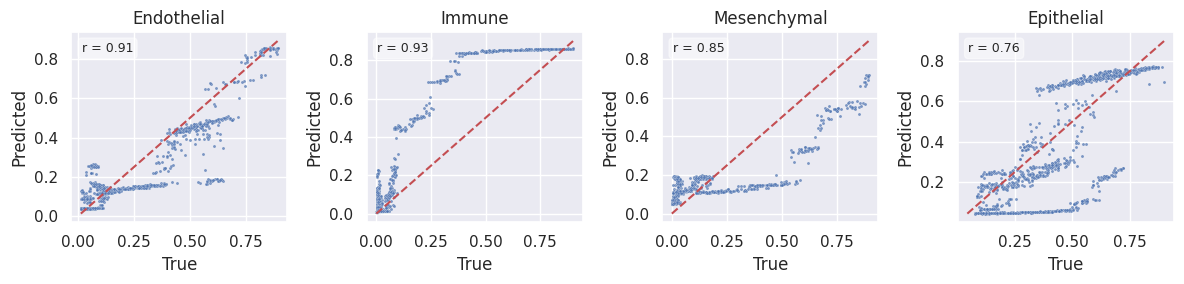

In [59]:
# Plot correlations (pearson)
plot_true_vs_predicted(test_czi_cell_prop,predicted_proportions_test)

### Compare distribution of Geneformer embeddings gotten from training and test sets 

In [68]:
print(pseudobulk_czi.shape)
print(test_czi.shape)

(3000, 36592)
(1000, 36592)


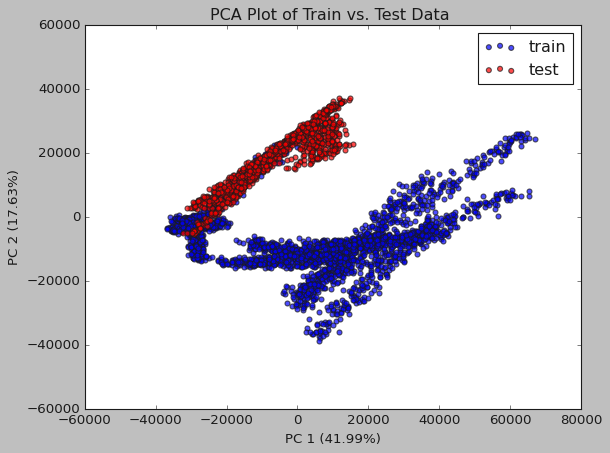

In [69]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Assuming pseudobulk_czi and test_czi are pandas DataFrames with identical columns
# and the shapes you provided: (1000, 36592) and (1000, 36592).

# Step 1: Merge the two dataframes and add a 'source' column
pseudobulk_df_with_source = pseudobulk_czi.copy()
pseudobulk_df_with_source['source'] = 'train'

test_df_with_source = test_czi.copy()
test_df_with_source['source'] = 'test'

#test_df_with_source_2 = test_czi_test.copy()
#test_df_with_source_2['source'] = 'test 2'

merged_df = pd.concat([pseudobulk_df_with_source, test_df_with_source], ignore_index=True)

# Step 2: Prepare data for PCA
# The source column needs to be dropped for the PCA calculation
X = merged_df.drop('source', axis=1)

# Step 3: Perform PCA
# We will reduce the dimensionality to 2 principal components for visualization
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

# Step 4: Create a new DataFrame for plotting
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['source'] = merged_df['source']

# Step 5: Plot the PCA results
plt.figure(figsize=(8, 6))

# Get unique sources for different colors
sources = pca_df['source'].unique()
colors = ['blue', 'red', 'green']  # Or any other color scheme

for i, source in enumerate(sources):
    # Filter the data for each source
    subset = pca_df[pca_df['source'] == source]
    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        c=colors[i],
        label=source,
        alpha=0.7
    )

# Add labels and title
plt.xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('PCA Plot of Train vs. Test Data ')
plt.legend()
plt.grid(False)
plt.show()

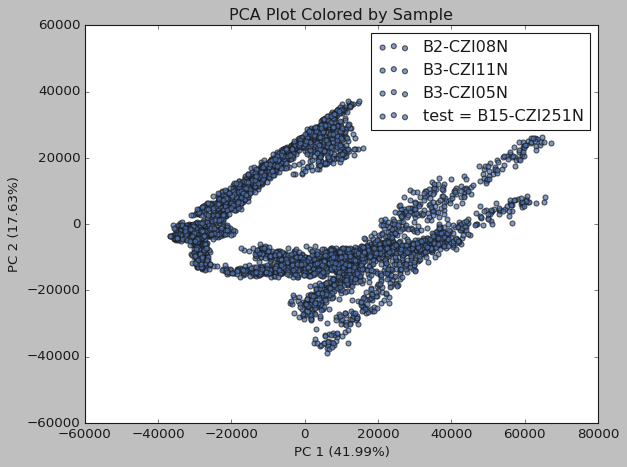

In [70]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Assume pseudobulk_czi and test_czi are (1000, 36592). "B4P4-CZI04N", "B4P1-CZI01N","B3-CZI05N"
# Merge with 'source' column
pseudobulk_df_with_source = pseudobulk_czi.copy()
pseudobulk_df_with_source['source'] = 'train'

test_df_with_source = test_czi.copy()
test_df_with_source['source'] = 'test'

merged_df = pd.concat([pseudobulk_df_with_source, test_df_with_source], ignore_index=True)

# -----------------------------
# Create custom sample label list 'B2-CZI08N', 'B3-CZI11N', 'B3-CZI05N'
# -----------------------------
sample_labels = ['B2-CZI08N'] * 1000 + ['B3-CZI11N'] * 1000 + ['B3-CZI05N'] * 1000 + ['test = B15-CZI251N'] * 1000
merged_df['sample'] = sample_labels

# PCA input (excluding 'source' and 'sample')
X = merged_df.drop(['source', 'sample'], axis=1)

# PCA computation
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

# Create plot DataFrame
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['sample'] = merged_df['sample']

# Plot
plt.figure(figsize=(8, 6))

for sample in pca_df['sample'].unique():
    subset = pca_df[pca_df['sample'] == sample]
    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        label=sample,
        alpha=0.7
    )

plt.xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('PCA Plot Colored by Sample')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

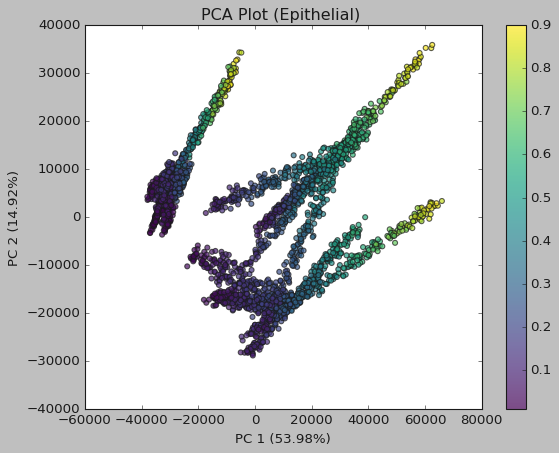

In [71]:
data_for_pca = pseudobulk_czi.copy()
data_for_pca['Epithelial'] = pseudobulk_czi_cell_prop['Epithelial']

# Step 2: Prepare data for PCA
# Drop the 'Epithelial' column as it's a label, not a feature
X = data_for_pca.drop('Epithelial', axis=1)

# Step 3: Perform PCA
# Reduce the dimensionality to 2 principal components
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

# Step 4: Create a new DataFrame for plotting
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
# Add the 'Epithelial' column for coloring
pca_df['Epithelial'] = np.array(data_for_pca['Epithelial'])

# Step 5: Plot the PCA results
plt.figure(figsize=(8, 6))

# Plot the PCA results using 'Epithelial' as a continuous color variable.
# A continuous color map (cmap) is used instead of a discrete list of colors.
scatter = plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['Epithelial'],  # Use the numeric 'Epithelial' values for coloring
    cmap='viridis',          # Specify a continuous colormap
    alpha=0.7
)

# Add a color bar to the plot to show the continuous scale
cbar = plt.colorbar(scatter)
cbar.set_label('')

# Add labels and title
plt.xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('PCA Plot (Epithelial) ')
plt.grid(False)
plt.show()

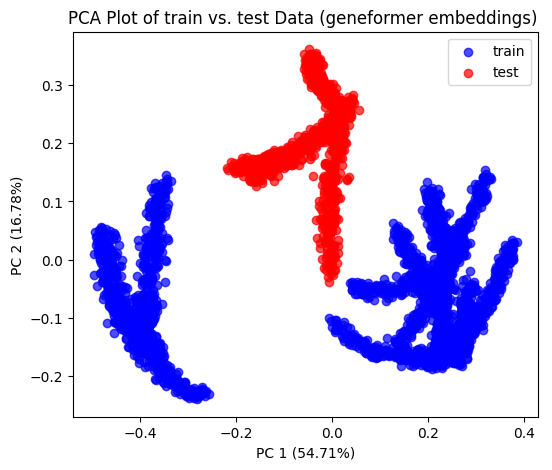

In [82]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Assuming pseudobulk_czi and test_czi are pandas DataFrames with identical columns
# and the shapes you provided: (1000, 36592) and (1000, 36592).

# Step 1: Merge the two dataframes and add a 'source' column
pseudobulk_df_with_source = latent_czi_pseudobulk.copy()
pseudobulk_df_with_source['source'] = 'train'

test_df_with_source = latent_czi_pseudobulk_test.copy()
test_df_with_source['source'] = 'test'


merged_df = pd.concat([pseudobulk_df_with_source, test_df_with_source], ignore_index=True)

metadata_concat = pd.concat([pseudobulk_czi_cell_prop, test_czi_cell_prop])

# Step 2: Prepare data for PCA
# The source column needs to be dropped for the PCA calculation
X = merged_df.drop('source', axis=1)

# Step 3: Perform PCA
# We will reduce the dimensionality to 2 principal components for visualization
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

# Step 4: Create a new DataFrame for plotting
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['source'] = merged_df['source']

# Step 5: Plot the PCA results
plt.figure(figsize=(6, 5))

# Get unique sources for different colors
sources = pca_df['source'].unique()
colors = ['blue', 'red', 'green']  # Or any other color scheme

for i, source in enumerate(sources):
    # Filter the data for each source
    subset = pca_df[pca_df['source'] == source]
    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        c=colors[i],
        label=source,
        alpha=0.7
    )

# Add labels and title
plt.xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('PCA Plot of train vs. test Data (geneformer embeddings) ')
plt.legend()
plt.grid(False)
plt.show()

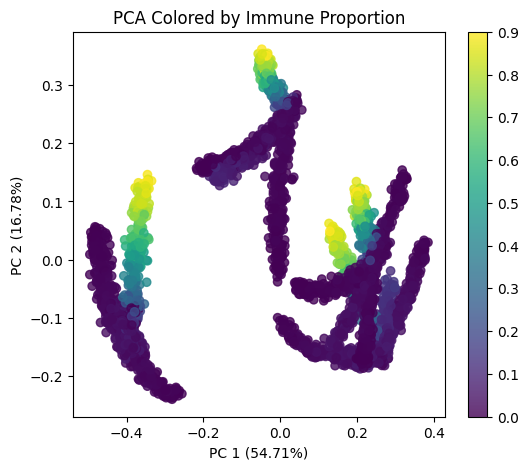

In [87]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Merge latent features and add source labels
pseudobulk_df_with_source = latent_czi_pseudobulk.copy()
pseudobulk_df_with_source['source'] = 'train'

test_df_with_source = latent_czi_pseudobulk_test.copy()
test_df_with_source['source'] = 'test'

merged_df = pd.concat([pseudobulk_df_with_source, test_df_with_source], ignore_index=True)

# Concatenate metadata
metadata_concat = pd.concat([pseudobulk_czi_cell_prop, test_czi_cell_prop], ignore_index=True)

# Ensure metadata index matches merged_df
metadata_concat = metadata_concat.reset_index(drop=True)

# Step 2: Drop 'source' before PCA
X = merged_df.drop('source', axis=1)

# Step 3: PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

# Step 4: Create PCA DataFrame
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Step 5: Add Epithelial values
pca_df['Epithelial'] = metadata_concat['Immune'].values

# Step 6: Plot PCA, colored by 'Epithelial'
plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    pca_df['PC1'], 
    pca_df['PC2'], 
    c=pca_df['Epithelial'], 
    cmap='viridis', 
    alpha=0.8
)

plt.xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('PCA Colored by Immune Proportion')
plt.colorbar(scatter, label='')
plt.grid(False)
plt.show()

### Standardize/Normalize scVI embeddings before training models

In [88]:
from sklearn.preprocessing import StandardScaler

In [89]:
# Define standard scaler
scaler = StandardScaler()

# Scale train set
latent_czi_pseudobulk_z = pd.DataFrame(
    scaler.fit_transform(latent_czi_pseudobulk),
    index=latent_czi_pseudobulk.index,
    columns=latent_czi_pseudobulk.columns
)

# scale test set
latent_czi_pseudobulk_test_z = pd.DataFrame(
    scaler.fit_transform(latent_czi_pseudobulk_test),
    index=latent_czi_pseudobulk_test.index,
    columns=latent_czi_pseudobulk_test.columns
)

# Define X and y 
X = latent_czi_pseudobulk_z
y = pseudobulk_czi_cell_prop.loc[latent_czi_pseudobulk_z.index, :]

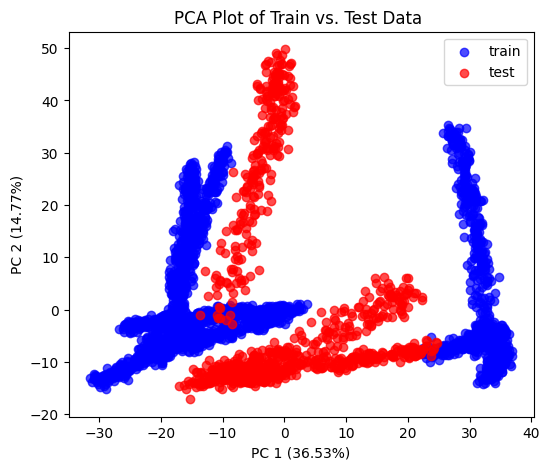

In [94]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Assuming pseudobulk_czi and test_czi are pandas DataFrames with identical columns
# and the shapes you provided: (1000, 36592) and (1000, 36592).

# Step 1: Merge the two dataframes and add a 'source' column
pseudobulk_df_with_source = latent_czi_pseudobulk_z.copy()
pseudobulk_df_with_source['source'] = 'train'

test_df_with_source = latent_czi_pseudobulk_test_z.copy()
test_df_with_source['source'] = 'test'

#test_df_with_source_2 = test_czi_test.copy()
#test_df_with_source_2['source'] = 'test 2'

merged_df = pd.concat([pseudobulk_df_with_source, test_df_with_source], ignore_index=True)

metadata_concat = pd.concat([pseudobulk_czi_cell_prop, test_czi_cell_prop])

# Step 2: Prepare data for PCA
# The source column needs to be dropped for the PCA calculation
X_pca = merged_df.drop('source', axis=1)

# Step 3: Perform PCA
# We will reduce the dimensionality to 2 principal components for visualization
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_pca)

# Step 4: Create a new DataFrame for plotting
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['source'] = merged_df['source']

# Step 5: Plot the PCA results
plt.figure(figsize=(6, 5))

# Get unique sources for different colors
sources = pca_df['source'].unique()
colors = ['blue', 'red', 'green']  # Or any other color scheme

for i, source in enumerate(sources):
    # Filter the data for each source
    subset = pca_df[pca_df['source'] == source]
    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        c=colors[i],
        label=source,
        alpha=0.7
    )

# Add labels and title
plt.xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('PCA Plot of Train vs. Test Data ')
plt.legend()
plt.grid(False)
plt.show()

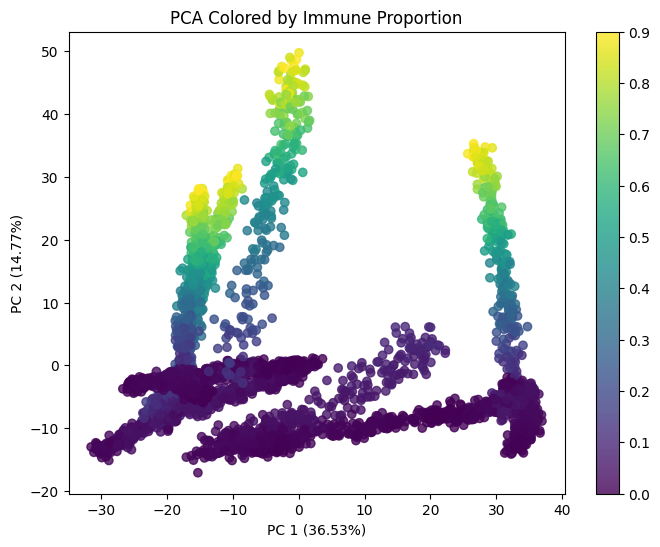

In [96]:
# visualize scaled data
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Merge latent features and add source labels
pseudobulk_df_with_source = latent_czi_pseudobulk_z.copy()
pseudobulk_df_with_source['source'] = 'train'

test_df_with_source = latent_czi_pseudobulk_test_z.copy()
test_df_with_source['source'] = 'test'

merged_df = pd.concat([pseudobulk_df_with_source, test_df_with_source], ignore_index=True)

# Concatenate metadata
metadata_concat = pd.concat([pseudobulk_czi_cell_prop, test_czi_cell_prop], ignore_index=True)

# Ensure metadata index matches merged_df
metadata_concat = metadata_concat.reset_index(drop=True)

# Step 2: Drop 'source' before PCA
X_pca = merged_df.drop('source', axis=1)

# Step 3: PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_pca)

# Step 4: Create PCA DataFrame
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Step 5: Add Epithelial values
pca_df['Epithelial'] = metadata_concat['Immune'].values

# Step 6: Plot PCA, colored by 'Epithelial'
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pca_df['PC1'], 
    pca_df['PC2'], 
    c=pca_df['Epithelial'], 
    cmap='viridis', 
    alpha=0.8
)

plt.xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('PCA Colored by Immune Proportion')
plt.colorbar(scatter, label='')
plt.grid(False)
plt.show()

In [97]:
# Split data into training and test splits (using z score normalized)

# Define X and y 
X = latent_czi_pseudobulk_z
y = pseudobulk_czi_cell_prop.loc[latent_czi_pseudobulk_z.index, :]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

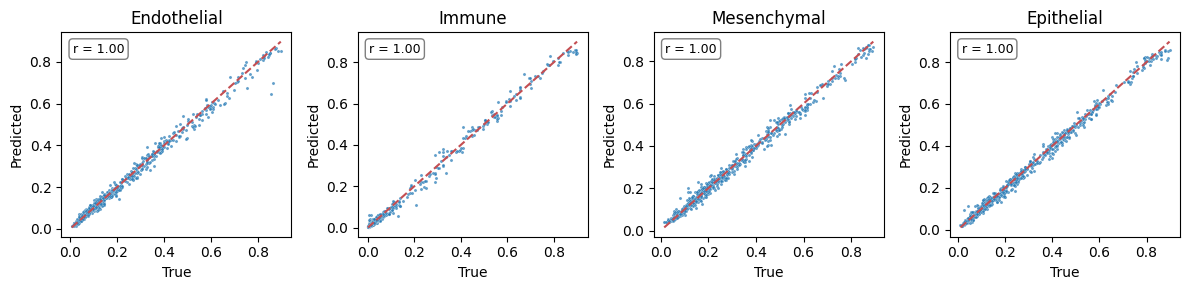

In [99]:
# Train model
from sklearn.ensemble import RandomForestRegressor

model_rf_scaled = RandomForestRegressor(n_estimators=500, random_state=42)
model_rf_scaled.fit(X_train, y_train)

# Assuming you have a DataFrame `X_bulk_latent` with same features as `X_train`
y_pred = model_rf_scaled.predict(X_test)

# Convert to DataFrame
predicted_proportions = pd.DataFrame(y_pred, columns=y_test.columns, index=X_test.index)

# Plot correlations (pearson)
plot_true_vs_predicted(y_test,predicted_proportions)

In [101]:
# Assuming you have a DataFrame `X_bulk_latent` with same features as `X_train`
y_pred = model_rf_scaled.predict(latent_czi_pseudobulk_test_z)

# Convert to DataFrame
predicted_proportions_test = pd.DataFrame(y_pred, columns=y_train.columns, index=test_czi.index)

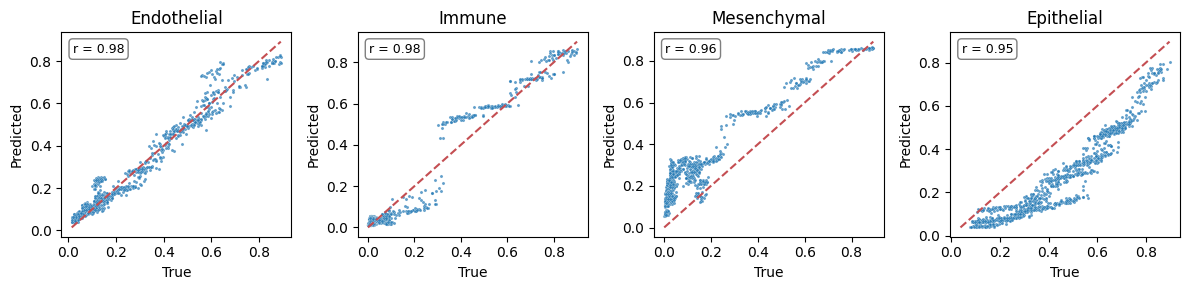

In [102]:
# Plot correlations (pearson)
plot_true_vs_predicted(test_czi_cell_prop,predicted_proportions_test)